#1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Dataset

In [2]:
df = pd.read_csv('/content/zomato_clean_dataset_india.csv')
df.head()


,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,cuisine_count,area_popularity,cost_numeric,cost_category,restaurant_type
0,Rainfall Restaurant - Flora Charishma,"Biryani, Chinese, South Indian, Kerala, North ...",₹700 for two,4.4,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,7,18,700.0,Medium,Premium
1,Zodiac - All Day Dining - Fortune Airport Road...,"North Indian, Chinese, South Indian, Continent...","₹2,000 for two",3.1,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,7,18,2000.0,High,Luxury
2,Thalassery Kitchen,"North Indian, Kerala, South Indian, Chinese, S...",₹500 for two,3.9,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,6,18,500.0,Low,Casual
3,Ila Restaurant Beirut Cafe,"Chinese, South Indian, Kerala",₹400 for two,4.0,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,3,18,400.0,Low,Casual
4,Paradise Restaurant,"Kerala, Biryani",₹300 for two,NaN,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,2,18,300.0,Low,Casual


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5493 entries, 0 to 5492
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 5493 non-null   object 
 1   cuisine              4922 non-null   object 
 2   price                5491 non-null   object 
 3   rating               5055 non-null   float64
 4   city                 5493 non-null   object 
 5   area                 5493 non-null   object 
 6   restaurant_link      5493 non-null   object 
 7   status               5493 non-null   object 
 8   has_online_delivery  5493 non-null   object 
 9   has_table_booking    5493 non-null   object 
 10  cuisine_count        5493 non-null   int64  
 11  area_popularity      5493 non-null   int64  
 12  cost_numeric         5491 non-null   float64
 13  cost_category        5493 non-null   object 
 14  restaurant_type      5493 non-null   object 
dtypes: float64(2), int64(2), object(11)
me

,rating,cuisine_count,area_popularity,cost_numeric
count,5055.000000,5493.000000,5493.000000,5491.000000
mean,4.243264,4.622064,19.750410,1049.557822
std,0.373660,2.471299,6.303718,782.539649
min,2.600000,1.000000,2.000000,40.000000
25%,4.000000,2.000000,18.000000,400.000000
50%,4.300000,5.000000,18.000000,1000.000000
75%,4.500000,7.000000,18.000000,1500.000000
max,4.900000,8.000000,54.000000,6000.000000


#3. EDA

## Missing Values

In [4]:

df.isnull().sum()

,0
name,0
cuisine,571
price,2
rating,438
city,0
area,0
restaurant_link,0
status,0
has_online_delivery,0
has_table_booking,0


## Rating Distribution

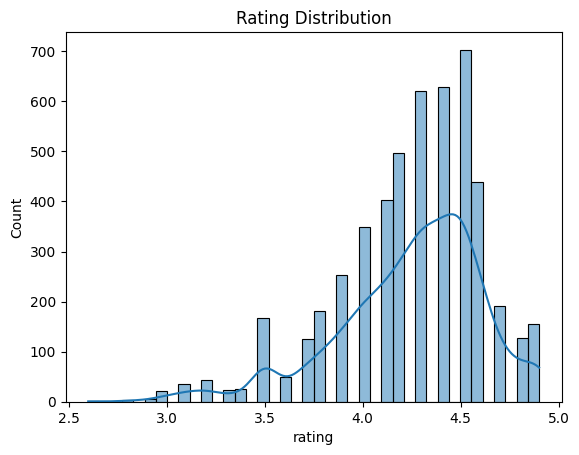

In [5]:
plt.figure()
sns.histplot(df['rating'], kde=True)
plt.title("Rating Distribution")
plt.show()

## Cost distribution

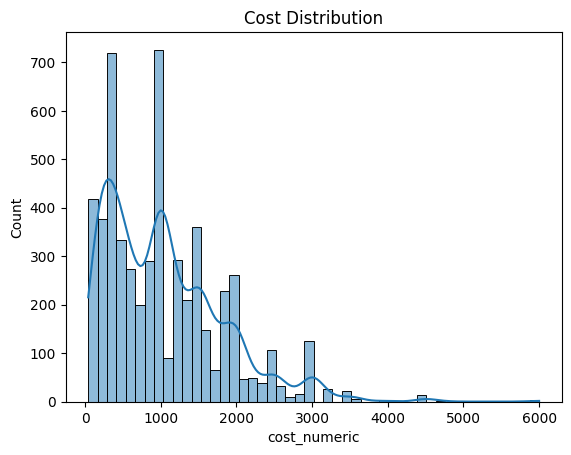

In [6]:
plt.figure()
sns.histplot(df['cost_numeric'], kde=True)
plt.title("Cost Distribution")
plt.show()

## Area Popularity

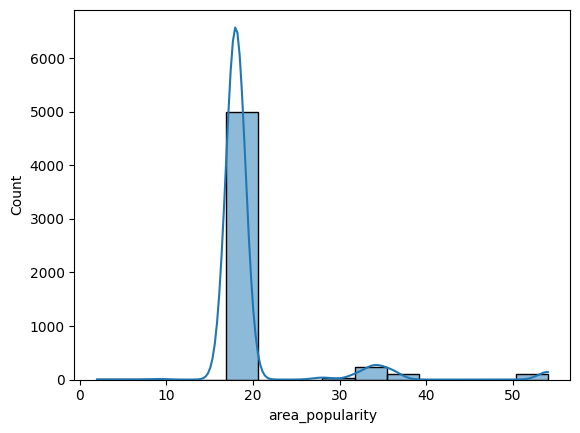

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['area_popularity'], kde=True)
plt.show()

## Correlation

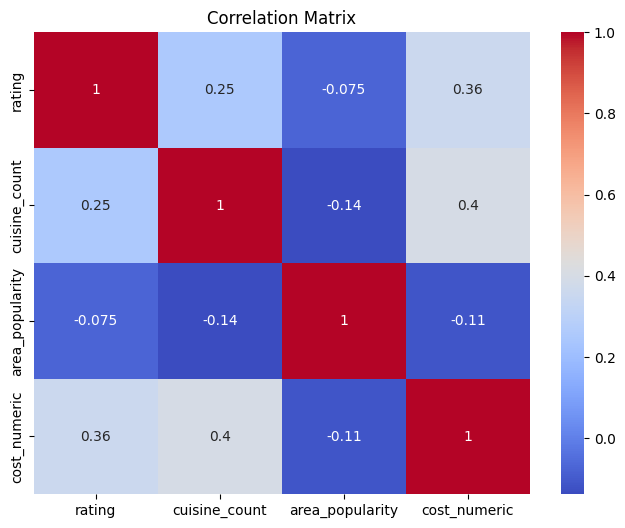

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##Scatter Plot

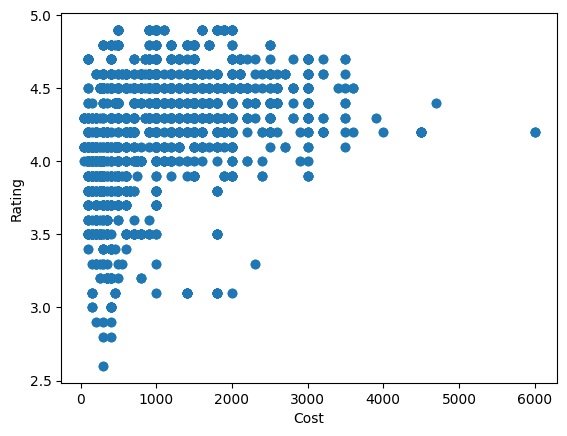

In [9]:


plt.scatter(df["cost_numeric"], df["rating"])
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.show()

## Outlier Detection

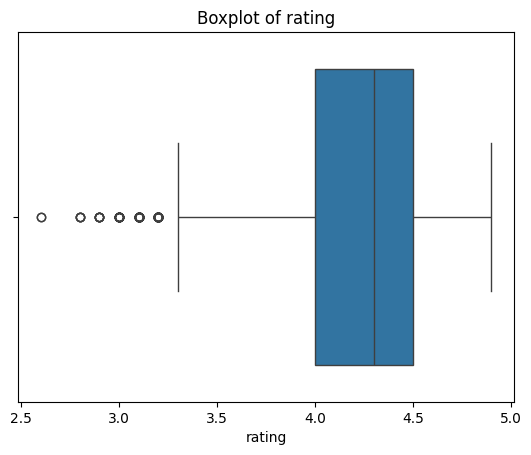

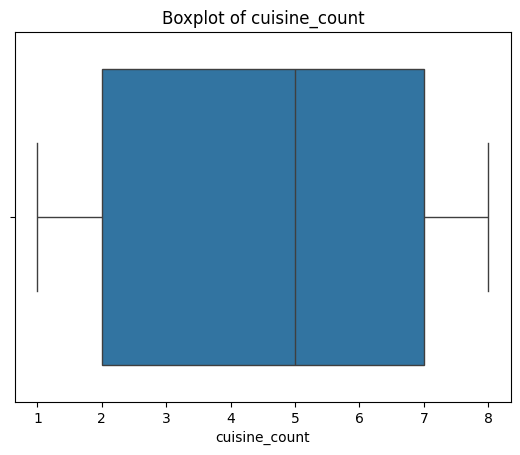

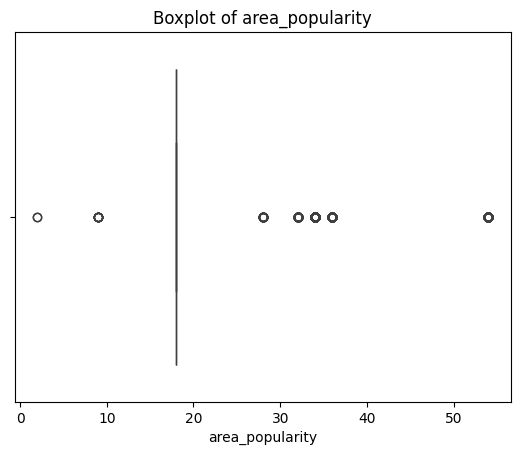

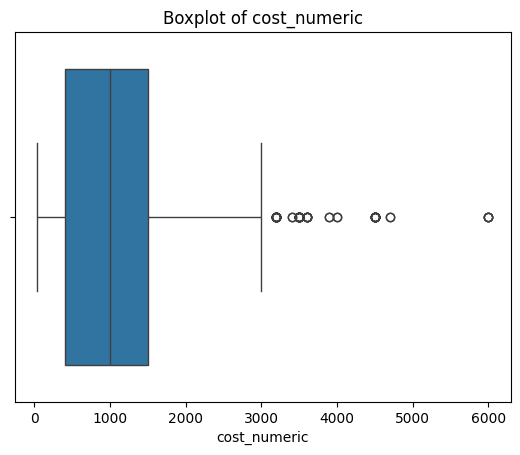

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [11]:
df.groupby("has_online_delivery")["rating"].mean()

,rating
has_online_delivery,
No,4.246552
Yes,4.240062


#4.Preprocessing

In [12]:
# Remove duplicates
df.drop_duplicates(subset=["name", "city", "area"], inplace=True)
print("Rows after duplicates:", len(df))



Rows after duplicates: 2745


In [13]:
# Clean rating
df['rating'] = df['rating'].astype(str).str.split('/').str[0]
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df = df.dropna(subset=['rating'])

In [14]:
df['rating']

,rating
0,4.4
1,3.1
2,3.9
3,4.0
6,3.6
...,...
5479,4.0
5480,3.7
5481,4.7
5482,4.1


In [15]:
# Fill missing values
df['cost_numeric'] = df['cost_numeric'].fillna(df['cost_numeric'].median())
df['cuisine'] = df['cuisine'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')

In [16]:
df.isnull().sum()

,0
name,0
cuisine,0
price,0
rating,0
city,0
area,0
restaurant_link,0
status,0
has_online_delivery,0
has_table_booking,0




#5. Feature Engineering



### City Tier

In [17]:

tier1 = ['mumbai', 'kolkata', 'bangalore','chennai','']
tier2 = ['Pune', 'Hyderabad', 'kochi', 'trivandrum','mysore','surat','lucknow']

def city_tier(city):
    if city in tier1:
        return 1
    elif city in tier2:
        return 2
    else:
        return 3

df['city_tier'] = df['city'].apply(city_tier)


### Cuisine Processing

In [18]:
df['cuisine_list'] = df['cuisine'].apply(lambda x: [i.strip() for i in str(x).split(',')])
df['cuisine_count'] = df['cuisine_list'].apply(len)


###Binary Encoding

In [19]:
df['has_online_delivery'] = df['has_online_delivery'].map({'Yes':1, 'No':0})

df['has_table_booking'] = df['has_table_booking'].map({'Yes':1, 'No':0})

df['status'] = df['status'].map({'Open':1, 'Close':0})

In [20]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,cuisine_count,area_popularity,cost_numeric,cost_category,restaurant_type,city_tier,cuisine_list
0,Rainfall Restaurant - Flora Charishma,"Biryani, Chinese, South Indian, Kerala, North ...",₹700 for two,4.4,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,1.0,0,1,7,18,700.0,Medium,Premium,2,"[Biryani, Chinese, South Indian, Kerala, North..."
1,Zodiac - All Day Dining - Fortune Airport Road...,"North Indian, Chinese, South Indian, Continent...","₹2,000 for two",3.1,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,1.0,1,0,7,18,2000.0,High,Luxury,2,"[North Indian, Chinese, South Indian, Continen..."
2,Thalassery Kitchen,"North Indian, Kerala, South Indian, Chinese, S...",₹500 for two,3.9,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,1.0,0,1,6,18,500.0,Low,Casual,2,"[North Indian, Kerala, South Indian, Chinese, ..."
3,Ila Restaurant Beirut Cafe,"Chinese, South Indian, Kerala",₹400 for two,4.0,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,1.0,0,1,3,18,400.0,Low,Casual,2,"[Chinese, South Indian, Kerala]"
6,Meenchatti Restaurant,"Kerala, North Indian, Chinese, Sichuan, Beverages",₹300 for two,3.6,kochi,aluva,https://www.zomato.com/kochi/meenchatti-restau...,1.0,0,0,5,18,300.0,Low,Casual,2,"[Kerala, North Indian, Chinese, Sichuan, Bever..."


## Cuisine Encoding ---> Multilabel Binarizer

In [21]:
from sklearn.preprocessing import MultiLabelBinarizer

top_cuisines = df['cuisine_list'].explode().value_counts().head(15).index

df['cuisine_list'] = df['cuisine_list'].apply(
    lambda x: [i for i in x if i in top_cuisines]
)

mlb = MultiLabelBinarizer()
cuisine_encoded = mlb.fit_transform(df['cuisine_list'])

cuisine_df = pd.DataFrame(cuisine_encoded, columns=mlb.classes_)

df = pd.concat([df.reset_index(drop=True), cuisine_df], axis=1)

In [22]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,Coffee,Continental,Desserts,Fast Food,Italian,North Indian,Pizza,Sandwich,South Indian,Unknown
0,Rainfall Restaurant - Flora Charishma,"Biryani, Chinese, South Indian, Kerala, North ...",₹700 for two,4.4,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,1.0,0,1,...,0,0,0,0,0,1,0,0,1,0
1,Zodiac - All Day Dining - Fortune Airport Road...,"North Indian, Chinese, South Indian, Continent...","₹2,000 for two",3.1,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,1.0,1,0,...,0,1,0,0,0,1,0,1,1,0
2,Thalassery Kitchen,"North Indian, Kerala, South Indian, Chinese, S...",₹500 for two,3.9,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,1.0,0,1,...,0,0,0,0,0,1,0,0,1,0
3,Ila Restaurant Beirut Cafe,"Chinese, South Indian, Kerala",₹400 for two,4.0,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,1.0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,Meenchatti Restaurant,"Kerala, North Indian, Chinese, Sichuan, Beverages",₹300 for two,3.6,kochi,aluva,https://www.zomato.com/kochi/meenchatti-restau...,1.0,0,0,...,0,0,0,0,0,1,0,0,0,0


### Encoding Cost category

In [23]:
cost_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["cost_category_encoded"] = df["cost_category"].map(cost_map)

## Encoding Restaurent type ----> One Hot Encoder

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[["restaurant_type"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["restaurant_type"])
)

df = pd.concat([df, encoded_df], axis=1)

In [25]:
df.head(1)

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,Fast Food,Italian,North Indian,Pizza,Sandwich,South Indian,Unknown,cost_category_encoded,restaurant_type_Luxury,restaurant_type_Premium
0,Rainfall Restaurant - Flora Charishma,"Biryani, Chinese, South Indian, Kerala, North ...",₹700 for two,4.4,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,1.0,0,1,...,0,0,1,0,0,1,0,1,0.0,1.0


## Final Data set

In [26]:
df_final = df.drop(columns=[
    'name', 'cuisine', 'cuisine_list','price',
    'cost_category', 'city','area','restaurant_link','restaurant_type',
])

df_final = df_final.dropna()

In [27]:
df_final.head(1)

,rating,status,has_online_delivery,has_table_booking,cuisine_count,area_popularity,cost_numeric,city_tier,Asian,Beverages,...,Fast Food,Italian,North Indian,Pizza,Sandwich,South Indian,Unknown,cost_category_encoded,restaurant_type_Luxury,restaurant_type_Premium
0,4.4,1.0,0,1,7,18,700.0,2,0,0,...,0,0,1,0,0,1,0,1,0.0,1.0


## Splitting Dataset for training

In [28]:
from sklearn.model_selection import train_test_split

X = df_final.drop('rating', axis=1)
y = df_final['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scaling Dataset

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelling

## Linear Regression, Lasso Regression, Ridge

In [30]:
from sklearn.linear_model import LinearRegression, Lasso,Ridge

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error

In [87]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE:", root_mean_squared_error(y_test, lr_pred))

Linear Regression:
MAE: 0.2373241711127666
R2 Score: 0.24972162434323386
MSE: 0.1028682562211522
RMSE: 0.3207308158271547


In [88]:
lasso = Lasso(alpha=0.1)  # alpha = regularization strength
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print("\nLasso Regression:")
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("R2 Score:", r2_score(y_test, lasso_pred))
print("MSE:", mean_squared_error(y_test, lasso_pred))
print("RMSE:", root_mean_squared_error(y_test, lasso_pred))


Lasso Regression:
MAE: 0.26958194527363105
R2 Score: 0.0864306238181689
MSE: 0.12525656038347968
RMSE: 0.35391603578176517


In [89]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("\nRidge Regression:")
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("R2 Score:", r2_score(y_test, ridge_pred))
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("RMSE:", root_mean_squared_error(y_test, ridge_pred))


Ridge Regression:
MAE: 0.23731386956147738
R2 Score: 0.24974472845763807
MSE: 0.10286508849029735
RMSE: 0.32072587748776576


## SVM regressor, KNN Regressor

In [35]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [90]:
svm = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

print("SVM Regression:")
print("MAE:", mean_absolute_error(y_test, svm_pred))
print("R2 Score:", r2_score(y_test, svm_pred))
print("MSE:", mean_squared_error(y_test, svm_pred))
print("RMSE:", root_mean_squared_error(y_test, svm_pred))

SVM Regression:
MAE: 0.17894941649066576
R2 Score: 0.5050453517904658
MSE: 0.06786164072141808
RMSE: 0.2605026693172607


In [91]:
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')

knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("\nKNN Regression:")
print("MAE:", mean_absolute_error(y_test, knn_pred))
print("R2 Score:", r2_score(y_test, knn_pred))
print("MSE:", mean_squared_error(y_test, knn_pred))
print("RMSE:", root_mean_squared_error(y_test, knn_pred))


KNN Regression:
MAE: 0.14609000040247472
R2 Score: 0.5029930652920034
MSE: 0.06814302312588662
RMSE: 0.26104218648694816


# Tree based Modelling

## Decision Tree Regressor

In [39]:
from sklearn.tree import DecisionTreeRegressor

In [92]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, dt_pred))
print("R2:", r2_score(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("RMSE:", root_mean_squared_error(y_test, dt_pred))

MAE: 0.21716879431150735
R2: 0.3455018367714582
MSE: 0.08973613919277824
RMSE: 0.29955990918809255


## Random Forest Regressor

In [70]:
from sklearn.ensemble import RandomForestRegressor

In [93]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))

MAE: 0.1206488544191865
R2: 0.6984348984799473
MSE: 0.04134662165008752
RMSE: 0.2033386870472206


## Gradient Booster Regressor

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

In [73]:
gbr = GradientBoostingRegressor(

    random_state=42
)

gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [74]:
gbr_pred = gbr.predict(X_test)

In [94]:
print("Gradient Boosting Regression:")
print("MAE:", mean_absolute_error(y_test, gbr_pred))
print("R2 Score:", r2_score(y_test, gbr_pred))
print("MSE:", mean_squared_error(y_test, gbr_pred))
print("RMSE:", root_mean_squared_error(y_test, gbr_pred))

Gradient Boosting Regression:
MAE: 0.21719057967899588
R2 Score: 0.38368638591911464
MSE: 0.08450077840822692
RMSE: 0.2906901759747428


##XGBooster Regressor

In [76]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [78]:
xgb = XGBRegressor()



xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [79]:
xgb_pred = xgb.predict(X_test)

In [95]:
print("XGBoost Regression:")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("R2 Score:", r2_score(y_test, xgb_pred))
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("RMSE:", root_mean_squared_error(y_test, xgb_pred))

XGBoost Regression:
MAE: 0.1288984109323921
R2 Score: 0.6605326524281052
MSE: 0.04654327676467091
RMSE: 0.21573890878715157


In [97]:
results = [
    {"Model": "Linear Regression", "MAE": mean_absolute_error(y_test, lr_pred), "R2 Score": r2_score(y_test, lr_pred),"MSE": mean_squared_error(y_test, lr_pred),"RMSE": root_mean_squared_error(y_test, lr_pred)},

    {"Model": "Lasso", "MAE": mean_absolute_error(y_test, lasso_pred), "R2 Score": r2_score(y_test, lasso_pred),"MSE": mean_squared_error(y_test, lasso_pred),"RMSE": root_mean_squared_error(y_test, lasso_pred)},

    {"Model": "Ridge", "MAE": mean_absolute_error(y_test, ridge_pred), "R2 Score": r2_score(y_test, ridge_pred),"MSE": mean_squared_error(y_test, ridge_pred),"RMSE": root_mean_squared_error(y_test, ridge_pred)},

    {"Model": "SVM", "MAE": mean_absolute_error(y_test, svm_pred), "R2 Score": r2_score(y_test, svm_pred),"MSE": mean_squared_error(y_test, svm_pred),"RMSE": root_mean_squared_error(y_test, svm_pred)},

    {"Model": "KNN", "MAE": mean_absolute_error(y_test, knn_pred), "R2 Score": r2_score(y_test, knn_pred),"MSE": mean_squared_error(y_test, knn_pred),"RMSE": root_mean_squared_error(y_test, knn_pred)},

    {"Model": "Decision Tree", "MAE": mean_absolute_error(y_test, dt_pred), "R2 Score": r2_score(y_test, dt_pred),"MSE": mean_squared_error(y_test, dt_pred),"RMSE": root_mean_squared_error(y_test, dt_pred)},

    {"Model": "Random Forest", "MAE": mean_absolute_error(y_test, rf_pred), "R2 Score": r2_score(y_test, rf_pred),"MSE": mean_squared_error(y_test, rf_pred),"RMSE": root_mean_squared_error(y_test, rf_pred)},

    {"Model": "Gradient Boosting", "MAE": mean_absolute_error(y_test, gbr_pred), "R2 Score": r2_score(y_test, gbr_pred), "MSE": mean_squared_error(y_test, gbr_pred),"RMSE": root_mean_squared_error(y_test, gbr_pred)},

    {"Model": "XGBoost", "MAE": mean_absolute_error(y_test, xgb_pred), "R2 Score": r2_score(y_test, xgb_pred),"MSE": mean_squared_error(y_test, xgb_pred),"RMSE": root_mean_squared_error(y_test, xgb_pred)},

]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

               Model       MAE  R2 Score       MSE      RMSE
6      Random Forest  0.120649  0.698435  0.041347  0.203339
8            XGBoost  0.128898  0.660533  0.046543  0.215739
3                SVM  0.178949  0.505045  0.067862  0.260503
4                KNN  0.146090  0.502993  0.068143  0.261042
7  Gradient Boosting  0.217191  0.383686  0.084501  0.290690
5      Decision Tree  0.217169  0.345502  0.089736  0.299560
2              Ridge  0.237314  0.249745  0.102865  0.320726
0  Linear Regression  0.237324  0.249722  0.102868  0.320731
1              Lasso  0.269582  0.086431  0.125257  0.353916


## Selected Model Random Forest Regressor

## Tuning the model

In [100]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='r2',
                    n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_rf = grid.best_estimator_

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [102]:
y_pred_best = best_rf.predict(X_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

print('Tuned Random Forest ')
print('MSE: ',mean_squared_error(y_test,y_pred_best))
print('MAE: ',mean_absolute_error(y_test,y_pred_best))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred_best) ))
print('R2:',r2_score(y_test,y_pred_best))

Tuned Random Forest 
MSE:  0.04017168078225432
MAE:  0.11843830403623028
RMSE:  0.2004287424055101
R2: 0.7070044296277825


##Modelling with scaled data

In [103]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))

MAE: 0.12077887805984841
R2: 0.6979605949293014
MSE: 0.04141165188520758
RMSE: 0.20349853042517918


###R2 score has no change

## Feature Importance

In [104]:
import pandas as pd

importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                  Feature  Importance
5            cost_numeric    0.364974
3           cuisine_count    0.130734
15              Fast Food    0.044886
20           South Indian    0.036214
6               city_tier    0.034254
14               Desserts    0.033136
11                Chinese    0.032922
8               Beverages    0.029623
10                   Cafe    0.028321
22  cost_category_encoded    0.027691
